In [1]:
import numpy as np
import scipy
from matplotlib import pyplot as plt
from plotscripts import getimagedata, subtract
from module import import_ab
from skimage.restoration import inpaint_biharmonic
from skimage import img_as_float
from skimage.transform import resize
from scipy.ndimage import gaussian_filter

In [2]:
# Parameters

n    = 1001
FoV  = 40 # uas

In [3]:
# Grid generation

a    = FoV * ((np.arange(n) + 0.5) / n - 0.5)
b    = FoV * ((np.arange(n) + 0.5) / n - 0.5)
A, B = np.meshgrid(a, b)

In [4]:
# # Synthetic data generation

# Img  = np.exp(-(A*A + B*B)/(2*256)) - np.exp(-(A*A + B*B)/(2*64))
# Img  = np.maximum(Img, 0)
# Img[72:78,:] = 0
# Img[:,34:36] = 0

# plt.imshow(Img.T, origin='lower')

In [18]:
img_path = "cache/Ma101_w1/Rh1_i60"
_, _, _, Img = subtract(img_path+"/n100", img_path+"/n0", 999 , ave=False)
# data_id_all, min, max, Img = getimagedata(img_path+'/n0', 1000)


read from cache/Ma101_w1/Rh1_i60/n100 and cache/Ma101_w1/Rh1_i60/n0
Reading in:  cache/Ma101_w1/Rh1_i60/n100/img_data_999.h5
8
Reading in:  cache/Ma101_w1/Rh1_i60/n0/img_data_999.h5
8
Reading in:  cache/Ma101_w1/Rh1_i60/n100/img_data_1000.h5
8


(-6.0, 6.0)

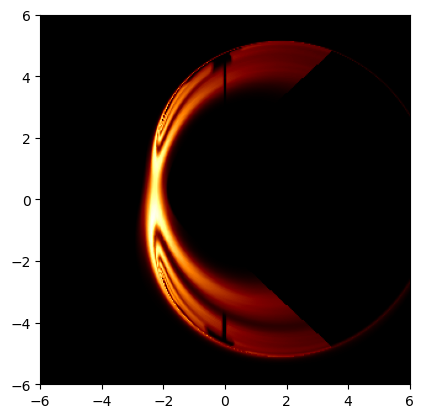

In [32]:
plt.imshow((Img/np.max(Img))**0.5, vmin=0.0, vmax=1.0, cmap='afmhot', origin='lower', extent=[-20,20,-20,20])
# ax.plot(alpha1, beta1, linewidth=1, color='deepskyblue', linestyle='-')

plt.xlim(-6,6)
plt.ylim(-6,6)

500


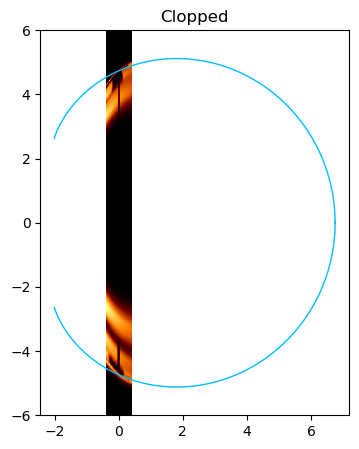

In [30]:
# get pixles along x=0
center_x = Img.shape[1] // 2
print(center_x)
epsilon = 20
x_start = center_x - epsilon
x_end   = center_x + epsilon
Img_band = Img[:, x_start:x_end]


fig, ax = plt.subplots(1, 1, figsize=(10, 5))
extent_band = [(-epsilon * 20 / 1000), (epsilon * 20 / 1000), -20, 20]

ax.imshow(( Img_band/np.max(Img_band))**0.5, vmin=0.0, vmax=1.0, cmap='afmhot', origin='lower', extent=extent_band)
ax.set_title('Clopped')
ax.plot(alpha1, beta1, linewidth=1, color='deepskyblue', linestyle='-')

# ax.set_xlim(-6,6)
ax.set_ylim(-6,6)
plt.show()


In [21]:
#get critical curve 
alpha1, beta1 = import_ab(1.01, 60, True) 

# critical curve in r, phi
r = np.sqrt(alpha1**2 + beta1**2)
PHI = np.arctan2(beta1, alpha1) 

def f(phi): 
    R = np.sqrt(alpha1**2 + beta1**2)
    inds=[]

    for p in phi:
        dPHI = np.abs(PHI - p)
        ind = np.nanargmin(dPHI) 
        inds.append(ind)
     
    inds = np.array(inds)
   
    phi_new = PHI[inds]
    r_new = R[inds]
    print(f"r_new : {r_new.shape}")
    return r_new, phi_new

# scikit Image 

In [22]:
Img_float = img_as_float(Img_band)
mask_small = Img_float <= 0

# Img_smooth = gaussian_filter(Img_float, sigma=3)
# image_filled = inpaint_biharmonic(Img_smooth, mask_small)

In [23]:
# Get coordinates
i_band, j_band = np.where(mask_small)
x_band = (j_band + x_start + 0.5) * FoV / Img.shape[1] - FoV/2
y_band = (i_band + 0.5) * FoV / Img.shape[0] - FoV/2

r_band = np.sqrt(x_band**2 + y_band**2)
phi_band = np.arctan2(y_band, x_band)
r_crit_local = f(phi_band)[0]

# Keep only pixels near the ring
threshold = 0.5  # mas
keep = np.abs(r_band - r_crit_local) < threshold
i_band = i_band[keep]
j_band = j_band[keep]

# Build refined mask
mask_refined = np.zeros_like(Img_band, dtype=bool)
mask_refined[i_band, j_band] = True


r_new : (34546,)


In [24]:
image_filled = inpaint_biharmonic(Img_float, mask_refined)

In [25]:
print("Masked pixels:", np.sum(mask_refined), "out of", mask_refined.size)
print("NaNs:", np.isnan(Img_float).sum(), "Infs:", np.isinf(Img_float).sum())


Masked pixels: 477 out of 40000
NaNs: 0 Infs: 0


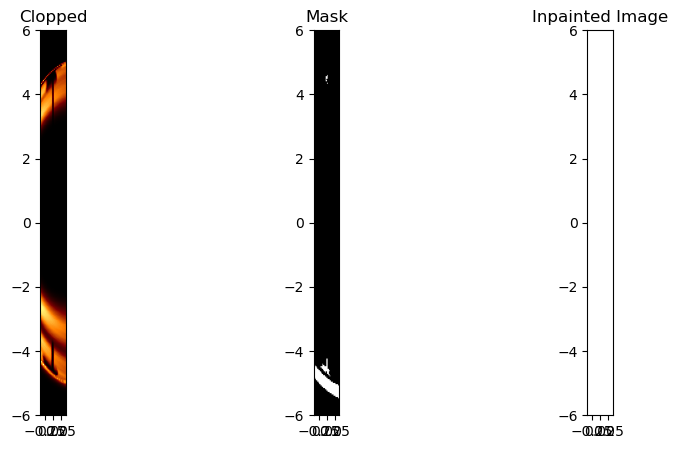

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(( Img_band/np.max(Img_band))**0.5, vmin=0.0, vmax=1.0, cmap='afmhot', origin='lower', extent=extent_band)
ax[0].set_title('Clopped')
ax[1].imshow(mask_refined, cmap='gray', extent=extent_band)
ax[1].set_title("Mask")
ax[2].imshow((image_filled/np.max(image_filled)) **0.5, vmin=0.0, vmax=1.0, cmap='afmhot', origin='lower', extent=extent_band)
ax[2].set_title('Inpainted Image')


# ax[0].set_xlim(-6,6)
# ax[1].set_xlim(-6,6)
ax[0].set_ylim(-6,6)
ax[1].set_ylim(-6,6)
# # ax[2].set_xlim(-6,6)
ax[2].set_ylim(-6,6)
plt.savefig('output/intp.png')
plt.show()


In [27]:
Img_fixed = Img.copy()
Img_fixed[:, x_start:x_end] = image_filled

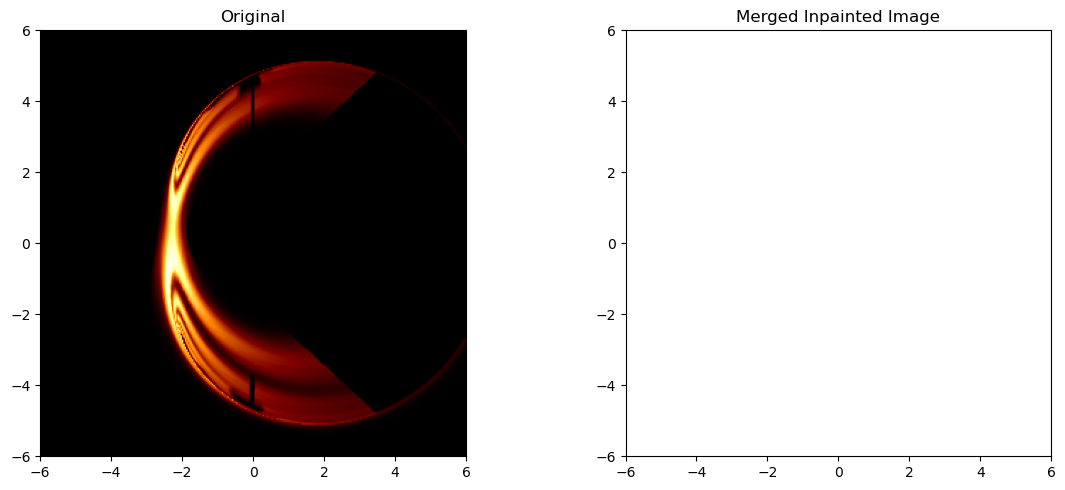

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow((Img / np.max(Img))**0.5, cmap='afmhot', origin='lower', extent=[-20, 20, -20, 20])
ax[0].set_title("Original")

ax[1].imshow((Img_fixed / np.max(Img_fixed))**0.5, cmap='afmhot', origin='lower', extent=[-20, 20, -20, 20])
ax[1].set_title("Merged Inpainted Image")

for a in ax:
    a.set_xlim(-6, 6)
    a.set_ylim(-6, 6)

plt.tight_layout()
plt.savefig('output/merged.png')
plt.show()


# scipy.interpolate.griddata

In [13]:
# Img[356]
# Img[630]
# Img[:, 424]
# Img[:, 672]
# Img = Img[356:630, 424:672]


In [41]:
# Find good data points that we can use to interpolate
#
# TODO: instead of picking all good data points,
# we may juse use the outlines of the bad regions.
Img_full = Img.copy()
center_x = Img_full.shape[1] // 2
print(center_x)
epsilon = 20
x_start = center_x - epsilon
x_end   = center_x + epsilon
extent_band = [(-epsilon * 20 / 1000), (epsilon * 20 / 1000), -20, 20]

Img = Img_full[:, x_start:x_end]
print(Img.shape)
print(Img_full.shape)

500
(1000, 40)
(1000, 1000)


In [42]:
# Coordinate transformation
#
# TODO: use a deformed spherical polar coordinates based on the critical curve

In [43]:

i_good, j_good = np.where(Img !=0)
Img_good = Img[(i_good, j_good)]

phi_good = np.arctan2(b[j_good], a[i_good])  # double check convention
r_good   = ( a[i_good] * a[i_good] + b[j_good] * b[j_good] )/ f(phi_good)[0]

r_new : (5454,)


In [44]:
# bad points
i_bad, j_bad = np.where(Img <=20)

In [45]:

Img_bad = Img[(i_bad, j_bad)]

phi_bad = np.arctan2(b[j_bad], a[i_bad])
r_bad   = ( a[i_bad] * a[i_bad] + b[j_bad] * b[j_bad] ) /f(phi_bad)[0]


r_new : (34546,)


In [46]:
#check dimensions
print(f'(r_good, phi_good) : ({r_good.shape}, {phi_good.shape})')
print(f'(r_bad, phi_bad) : ({r_bad.shape}, {phi_bad.shape})')
print(f'Img_good : {Img_good.shape}')
print(f'Img_bad : {r_bad}')


(r_good, phi_good) : ((5454,), (5454,))
(r_bad, phi_bad) : ((34546,), (34546,))
Img_good : (5454,)
Img_bad : [240.93113945 240.44975904 239.96934234 ... 118.85612767 118.59137926
 118.32726632]


In [47]:
Img_fill = scipy.interpolate.griddata((r_good, phi_good), Img_good, (r_bad, phi_bad), fill_value=0.0, method='nearest')

In [48]:
print(Img_fill)

[1.57057682e+08 1.57057682e+08 1.57057682e+08 ... 1.57057682e+08
 1.57057682e+08 1.57057682e+08]


In [49]:
Img_fixed = Img_full.copy()
Img_fixed[(i_bad, j_bad)] = Img_fill

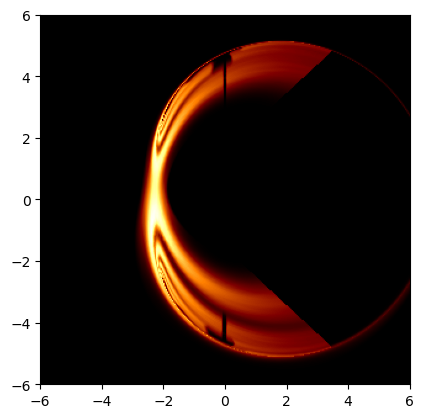

In [50]:
plt.imshow(Img_fixed**0.4, cmap='afmhot', origin='lower', extent=[-20,20,-20,20])
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.savefig('output/testinterpolation.png')

# TRY 1D per slices 

In [8]:
# alpha_band = A[:, x_start:x_end]
# beta_band  = B[:, x_start:x_end]

phi_grid = np.arctan2(b, a)
print(phi_grid.shape)
r_grid   = np.sqrt(a**2 + b**2)/ f(phi_grid)[0]

(1001,)


NameError: name 'f' is not defined

In [ ]:
i_good, j_good = np.where(Img != 0)
i_bad, j_bad   = np.where(Img == 0)

r_good   = r_grid[i_good, j_good]
phi_good = phi_grid[i_good, j_good]
Img_good = Img[i_good, j_good]

r_bad   = r_grid[i_bad, j_bad]
phi_bad = phi_grid[i_bad, j_bad]


In [ ]:
from scipy.interpolate import interp1d

Img_fill = np.zeros_like(r_bad)

for idx, (r0, phi0) in enumerate(zip(r_bad, phi_bad)):
    # Find good pixels within ±Δr of r0
    delta_r = 0.5  # adjust as needed
    mask_r = np.abs(r_good - r0) < delta_r
    
    if np.sum(mask_r) >= 3:
        phi_neighbors = phi_good[mask_r]
        val_neighbors = Img_good[mask_r]
        
        # Sort by phi for interpolation
        sort_idx = np.argsort(phi_neighbors)
        phi_sorted = phi_neighbors[sort_idx]
        val_sorted = val_neighbors[sort_idx]
        
        try:
            f_interp = interp1d(phi_sorted, val_sorted, kind='linear', fill_value=0.0, bounds_error=False)
            Img_fill[idx] = f_interp(phi0)
        except:
            Img_fill[idx] = 0.0
    else:
        Img_fill[idx] = 0.0


In [ ]:
plt.imshow((Img/np.max(Img))**0.5, vmin=0.0, vmax=1.0, cmap='afmhot', origin='lower', extent=[-20,20,-20,20])
plt.xlim(-6,6)
plt.ylim(-6,6)